# Sector Rotation & Tactical Allocation

**CQF-Level Example**: Professional sector rotation strategy:
- Relative strength momentum across sectors
- Business cycle regime mapping
- Risk-adjusted sector scoring
- Dynamic allocation with risk budgets
- Defensive rotation triggers

**Connectors Used:**
- `qj.eod` - Sector ETF prices
- `qj.fred` - Economic indicators (LEI, PMI, yields)
- `qj.fmp` - Sector fundamentals

**API:** https://api.quantjourney.cloud

## Preview Chart

![40_sector_rotation_momentum](../outputs/candidates/40_sector_rotation_momentum.png)

In [1]:
# Setup
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
from scipy import stats
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
pio.renderers.default = "png"

from quantjourney.sdk import QuantJourneyAPI

import os
API_KEY = os.environ.get("QJ_API_KEY", "qj_...")

qj = QuantJourneyAPI(api_key=API_KEY)
print("✓ Connected to QuantJourney API")


✓ Connected to QuantJourney API


## 1. Fetch Sector ETF Data

In [2]:
# SPDR Sector ETFs (Select Sector SPDRs)
sectors = {
    'XLK': 'Technology',
    'XLF': 'Financials',
    'XLV': 'Healthcare',
    'XLY': 'Consumer Discretionary',
    'XLP': 'Consumer Staples',
    'XLE': 'Energy',
    'XLI': 'Industrials',
    'XLB': 'Materials',
    'XLU': 'Utilities',
    'XLRE': 'Real Estate',
    'XLC': 'Communication Services'
}

benchmark = 'SPY'
start_date = '2015-01-01'
end_date = '2024-12-31'

prices = {}
all_symbols = list(sectors.keys()) + [benchmark]

for symbol in all_symbols:
    try:
        response = qj.eod.get_historical_prices(
            symbol=symbol,
            start_date=start_date,
            end_date=end_date,
            frequency='1d'
        )
        data = response.get('value', response) if isinstance(response, dict) else response
        if isinstance(data, list) and len(data) > 0:
            df = pd.DataFrame(data)
            df['date'] = pd.to_datetime(df['date'])
            df = df.set_index('date')
            prices[symbol] = df['adjusted_close' if 'adjusted_close' in df.columns else 'close']
            print(f"✓ {symbol}: {sectors.get(symbol, 'Benchmark')}")
    except Exception as e:
        print(f"✗ {symbol}: {e}")

# Fallback synthetic data
if len(prices) < 8:
    print("\nGenerating synthetic sector data...")
    dates = pd.date_range(start=start_date, end=end_date, freq='B')
    np.random.seed(42)
    
    # Sector characteristics (annual return, volatility)
    sector_params = {
        'XLK': (0.18, 0.22), 'XLF': (0.10, 0.20), 'XLV': (0.12, 0.15),
        'XLY': (0.14, 0.20), 'XLP': (0.08, 0.12), 'XLE': (0.05, 0.30),
        'XLI': (0.11, 0.18), 'XLB': (0.09, 0.20), 'XLU': (0.07, 0.14),
        'XLRE': (0.09, 0.18), 'XLC': (0.15, 0.22), 'SPY': (0.12, 0.16)
    }
    
    for sym in all_symbols:
        mu, sigma = sector_params.get(sym, (0.10, 0.18))
        ret = mu/252 + sigma/np.sqrt(252) * np.random.randn(len(dates))
        prices[sym] = pd.Series(100 * np.cumprod(1 + ret), index=dates)
        print(f"✓ {sym} (synthetic)")


✓ XLK: Technology
✓ XLF: Financials
✓ XLV: Healthcare
✓ XLY: Consumer Discretionary
✓ XLP: Consumer Staples
✓ XLE: Energy
✓ XLI: Industrials
✓ XLB: Materials
✓ XLU: Utilities
✓ XLRE: Real Estate
✓ XLC: Communication Services
✓ SPY: Benchmark


In [22]:
# Build price/returns matrices
prices_df = pd.DataFrame(prices).dropna()
returns_df = prices_df.pct_change().dropna()

sector_prices = prices_df[[s for s in sectors.keys() if s in prices_df.columns]]
sector_returns = returns_df[[s for s in sectors.keys() if s in returns_df.columns]]
benchmark_returns = returns_df[benchmark]

print(f"\nPeriod: {prices_df.index[0].date()} to {prices_df.index[-1].date()}")
print(f"Sectors: {len(sector_returns.columns)}")
print(f"Trading days: {len(sector_returns)}")



Period: 2018-06-19 to 2024-12-31
Sectors: 11
Trading days: 1644


## 2. Fetch Macro Regime Indicators

In [18]:
# Economic indicators from FRED
# Note: Some FRED series may not be available via the API - synthetic fallback used
macro_indicators = {
    'T10Y2Y': 'Yield Curve (10Y-2Y)',
    'BAMLH0A0HYM2': 'High Yield Spread',
    'INDPRO': 'Industrial Production',
    'UMCSENT': 'Consumer Sentiment',
    'DGS10': '10-Year Treasury (LEI proxy)'
}

macro_data = {}

def extract_fred_data(response, series_id):
    """Extract data from various FRED response formats"""
    if response is None:
        return None
    
    if isinstance(response, pd.DataFrame) and not response.empty:
        if series_id in response.columns:
            return pd.to_numeric(response[series_id], errors='coerce')
        elif 'value' in response.columns:
            return pd.to_numeric(response['value'], errors='coerce')
        else:
            return pd.to_numeric(response.iloc[:, 0], errors='coerce')
    
    elif isinstance(response, dict) and 'value' in response:
        data = response['value']
        if isinstance(data, list) and len(data) > 0:
            df = pd.DataFrame(data)
            df['date'] = pd.to_datetime(df['date'])
            df = df.set_index('date')
            value_cols = [c for c in df.columns if c not in ['realtime_start', 'realtime_end']]
            if 'value' in value_cols:
                return pd.to_numeric(df['value'], errors='coerce')
            elif value_cols:
                return pd.to_numeric(df[value_cols[0]], errors='coerce')
    return None

# Fetch available FRED data
for series_id, name in macro_indicators.items():
    try:
        response = qj.fred.get_fred_data_series_by_id(
            search_id=series_id,
            start=start_date,
            end=end_date
        )
        data = extract_fred_data(response, series_id)
        if data is not None and len(data) > 0:
            macro_data[series_id] = data
            print(f"✓ {series_id}: {name} ({len(data)} obs)")
    except Exception as e:
        print(f"✗ {series_id}: API error")

# Map DGS10 to USSLIND (use 10Y yield as leading indicator proxy)
if 'DGS10' in macro_data:
    macro_data['USSLIND'] = macro_data.pop('DGS10')

# Fallback: generate synthetic data for missing indicators
indicators_needed = ['USSLIND', 'INDPRO', 'UMCSENT', 'T10Y2Y', 'BAMLH0A0HYM2']
missing = [s for s in indicators_needed if s not in macro_data]

if missing:
    print(f"\nGenerating synthetic data for: {', '.join(missing)}")
    dates = pd.date_range(start=start_date, end=end_date, freq='ME')
    np.random.seed(123)
    cycle = np.sin(np.linspace(0, 4*np.pi, len(dates)))  # ~2 full economic cycles
    
    synthetic = {
        'USSLIND': pd.Series(100 + 5*cycle + np.random.randn(len(dates))*0.5, index=dates),
        'INDPRO': pd.Series(100 + 10*np.cumsum(0.002 + 0.01*cycle + np.random.randn(len(dates))*0.005), index=dates),
        'UMCSENT': pd.Series(80 + 15*cycle + np.random.randn(len(dates))*3, index=dates),
        'T10Y2Y': pd.Series(0.5 + 1.5*cycle + np.random.randn(len(dates))*0.2, index=dates),
        'BAMLH0A0HYM2': pd.Series(4 - 2*cycle + np.random.randn(len(dates))*0.5, index=dates)
    }
    
    for s in missing:
        macro_data[s] = synthetic[s]
        print(f"✓ {s} (synthetic)")

print(f"\nLoaded {len(macro_data)} macro indicators")


✓ T10Y2Y: Yield Curve (10Y-2Y) (2501 obs)
✓ BAMLH0A0HYM2: High Yield Spread (2612 obs)

Generating synthetic data for: USSLIND, INDPRO, UMCSENT
✓ USSLIND (synthetic)
✓ INDPRO (synthetic)
✓ UMCSENT (synthetic)

Loaded 5 macro indicators


In [19]:
# Build macro dataframe
macro_df = pd.DataFrame(macro_data)
macro_df = macro_df.ffill().dropna()

# Resample to monthly for regime detection
macro_monthly = macro_df.resample('ME').last()

print(f"\nMacro data: {macro_monthly.index[0].date()} to {macro_monthly.index[-1].date()}")
print(macro_monthly.tail())



Macro data: 2015-01-31 to 2024-12-31
            T10Y2Y  BAMLH0A0HYM2     USSLIND      INDPRO    UMCSENT
2024-08-31    0.00          3.17   98.089621  102.099473  72.670821
2024-09-30    0.15          3.03   97.756892  102.139944  72.454354
2024-10-31    0.12          2.88   98.785598  102.129264  83.024908
2024-11-30    0.05          2.74  100.452688  102.168427  72.753469
2024-12-31    0.33          2.92   98.987477  102.178472  76.615008


## 3. Business Cycle Regime Detection

In [20]:
def detect_economic_regime(macro_df):
    """
    Classify economic regime based on:
    - Growth (LEI momentum)
    - Yield curve (expansion/contraction signal)
    - Credit spreads (risk appetite)
    
    Regimes:
    1. Expansion (early): Growth ↑, Yield curve steep
    2. Expansion (late): Growth ↑, Yield curve flattening
    3. Contraction (early): Growth ↓, Spreads widening
    4. Contraction (late/Recovery): Growth bottoming, Spreads tightening
    """
    regimes = pd.DataFrame(index=macro_df.index)
    
    # LEI momentum (3-month change)
    if 'USSLIND' in macro_df.columns:
        regimes['lei_momentum'] = macro_df['USSLIND'].pct_change(3)
    else:
        regimes['lei_momentum'] = 0
    
    # Yield curve signal
    if 'T10Y2Y' in macro_df.columns:
        regimes['yield_curve'] = macro_df['T10Y2Y']
    else:
        regimes['yield_curve'] = 1
    
    # Credit spread z-score (12-month)
    if 'BAMLH0A0HYM2' in macro_df.columns:
        spread = macro_df['BAMLH0A0HYM2']
        regimes['spread_zscore'] = (spread - spread.rolling(12).mean()) / spread.rolling(12).std()
    else:
        regimes['spread_zscore'] = 0
    
    # Classify regime
    def classify_regime(row):
        lei = row['lei_momentum']
        yc = row['yield_curve']
        spread = row['spread_zscore']
        
        if pd.isna(lei) or pd.isna(yc):
            return 'Unknown'
        
        # Growth positive
        if lei > 0:
            if yc > 0.5:  # Steep curve
                return 'Early Expansion'
            else:
                return 'Late Expansion'
        # Growth negative
        else:
            if spread > 0.5:  # Spreads wide
                return 'Contraction'
            else:
                return 'Recovery'
    
    regimes['regime'] = regimes.apply(classify_regime, axis=1)
    
    return regimes

# Detect regimes
regime_df = detect_economic_regime(macro_monthly)

print("\nRegime Distribution:")
print(regime_df['regime'].value_counts())



Regime Distribution:
regime
Recovery           44
Late Expansion     37
Early Expansion    27
Contraction         9
Unknown             3
Name: count, dtype: int64


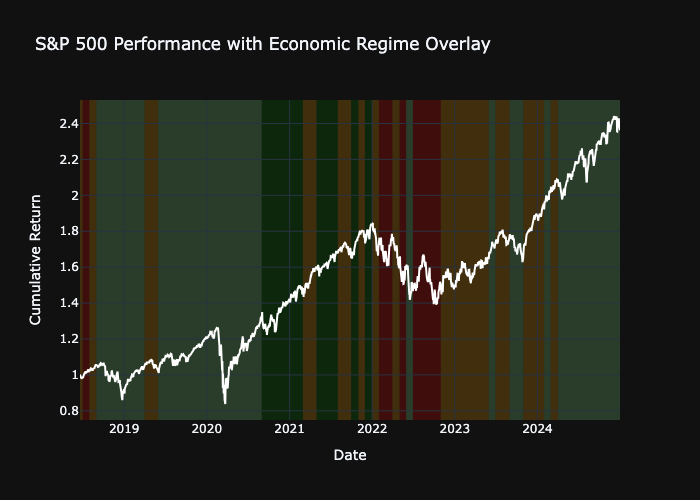

In [23]:
# Regime timeline
regime_colors = {
    'Early Expansion': 'green',
    'Late Expansion': 'lightgreen',
    'Contraction': 'red',
    'Recovery': 'orange',
    'Unknown': 'gray'
}

fig = go.Figure()

# Add benchmark performance
benchmark_cum = (1 + benchmark_returns).cumprod()
fig.add_trace(go.Scatter(
    x=benchmark_cum.index,
    y=benchmark_cum,
    mode='lines',
    name='S&P 500',
    line=dict(color='white', width=2)
))

# Add regime shading
regime_daily = regime_df['regime'].reindex(benchmark_cum.index, method='ffill')
for regime, color in regime_colors.items():
    mask = regime_daily == regime
    if mask.any():
        # Find contiguous regions
        changes = mask.astype(int).diff().fillna(0)
        starts = mask.index[changes == 1].tolist()
        ends = mask.index[changes == -1].tolist()
        
        if mask.iloc[0]:
            starts = [mask.index[0]] + starts
        if mask.iloc[-1]:
            ends = ends + [mask.index[-1]]
        
        for s, e in zip(starts[:len(ends)], ends):
            fig.add_vrect(
                x0=s, x1=e,
                fillcolor=color, opacity=0.2,
                layer='below', line_width=0
            )

fig.update_layout(
    title='S&P 500 Performance with Economic Regime Overlay',
    xaxis_title='Date',
    yaxis_title='Cumulative Return',
    template='plotly_dark',
    height=500
)
fig.show()


## 4. Sector Momentum Scoring

In [24]:
def calculate_momentum_scores(returns_df, lookbacks=[21, 63, 126, 252]):
    """
    Calculate multi-timeframe momentum scores:
    - 1M, 3M, 6M, 12M returns
    - Volatility-adjusted (risk-adjusted momentum)
    - Composite score with decay weighting
    """
    scores = pd.DataFrame(index=returns_df.index, columns=returns_df.columns)
    
    # Calculate returns for each lookback
    momentum = {}
    for lb in lookbacks:
        # Cumulative return over lookback
        cum_ret = (1 + returns_df).rolling(lb).apply(lambda x: x.prod() - 1, raw=False)
        # Volatility over lookback
        vol = returns_df.rolling(lb).std() * np.sqrt(252)
        # Risk-adjusted momentum
        momentum[lb] = cum_ret / vol
    
    # Composite score (exponential decay weighting, recent more important)
    weights = np.array([0.4, 0.3, 0.2, 0.1])  # 1M, 3M, 6M, 12M
    
    for i, lb in enumerate(lookbacks):
        if i == 0:
            scores = momentum[lb] * weights[i]
        else:
            scores = scores + momentum[lb] * weights[i]
    
    return scores

# Calculate momentum scores
momentum_scores = calculate_momentum_scores(sector_returns)

# Latest scores
latest_scores = momentum_scores.iloc[-1].sort_values(ascending=False)
print("\nLatest Sector Momentum Scores (Risk-Adjusted):")
for sym, score in latest_scores.items():
    sector_name = sectors.get(sym, sym)
    print(f"  {sym:5} ({sector_name:25}): {score:>7.3f}")



Latest Sector Momentum Scores (Risk-Adjusted):
  XLY   (Consumer Discretionary   ):   0.540
  XLC   (Communication Services   ):   0.518
  XLF   (Financials               ):   0.394
  XLK   (Technology               ):   0.197
  XLU   (Utilities                ):  -0.018
  XLI   (Industrials              ):  -0.045
  XLP   (Consumer Staples         ):  -0.139
  XLRE  (Real Estate              ):  -0.184
  XLE   (Energy                   ):  -0.291
  XLV   (Healthcare               ):  -0.505
  XLB   (Materials                ):  -0.643


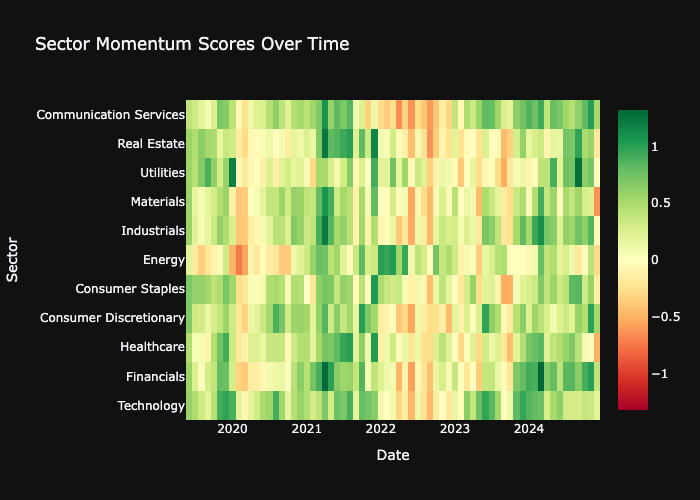

In [25]:
# Momentum score heatmap over time
monthly_scores = momentum_scores.resample('ME').last().dropna()

# Rename columns to sector names
monthly_scores_named = monthly_scores.rename(columns=sectors)

fig = go.Figure(data=go.Heatmap(
    z=monthly_scores_named.T.values,
    x=monthly_scores_named.index.strftime('%Y-%m'),
    y=monthly_scores_named.columns,
    colorscale='RdYlGn',
    zmid=0,
    hovertemplate='%{x}<br>%{y}: %{z:.2f}<extra></extra>'
))

fig.update_layout(
    title='Sector Momentum Scores Over Time',
    xaxis_title='Date',
    yaxis_title='Sector',
    template='plotly_dark',
    height=500
)
fig.show()


## 5. Sector-Regime Mapping

In [26]:
# Historical sector performance by regime
def analyze_sector_regime_performance(sector_returns, regime_df):
    """
    Analyze average sector performance in each economic regime
    """
    # Align regime to daily returns
    regime_daily = regime_df['regime'].reindex(sector_returns.index, method='ffill')
    
    # Calculate annualized return by regime
    results = {}
    for regime in regime_daily.dropna().unique():
        if regime == 'Unknown':
            continue
        mask = regime_daily == regime
        regime_returns = sector_returns[mask]
        
        # Annualized return
        ann_ret = regime_returns.mean() * 252
        # Annualized vol
        ann_vol = regime_returns.std() * np.sqrt(252)
        # Sharpe (assuming 0 rf for simplicity)
        sharpe = ann_ret / ann_vol
        
        results[regime] = {
            'return': ann_ret,
            'volatility': ann_vol,
            'sharpe': sharpe,
            'days': mask.sum()
        }
    
    return results

regime_performance = analyze_sector_regime_performance(sector_returns, regime_df)

# Display as table
for regime, data in regime_performance.items():
    print(f"\n{'='*60}")
    print(f"REGIME: {regime} ({data['days']} days)")
    print(f"{'='*60}")
    
    returns_sorted = data['return'].sort_values(ascending=False)
    print("\nTop Sectors:")
    for sym in returns_sorted.head(5).index:
        ret = data['return'][sym]
        vol = data['volatility'][sym]
        sr = data['sharpe'][sym]
        print(f"  {sectors.get(sym, sym):25} | Ret: {ret*100:>6.1f}% | Vol: {vol*100:>5.1f}% | SR: {sr:>5.2f}")



REGIME: Recovery (490 days)

Top Sectors:
  Technology                | Ret:   23.9% | Vol:  21.7% | SR:  1.10
  Communication Services    | Ret:   20.6% | Vol:  20.1% | SR:  1.02
  Energy                    | Ret:   15.2% | Vol:  24.5% | SR:  0.62
  Real Estate               | Ret:   14.6% | Vol:  18.9% | SR:  0.77
  Financials                | Ret:   14.0% | Vol:  16.7% | SR:  0.83

REGIME: Contraction (167 days)

Top Sectors:
  Energy                    | Ret:   91.5% | Vol:  33.7% | SR:  2.72
  Industrials               | Ret:   31.4% | Vol:  21.9% | SR:  1.43
  Financials                | Ret:   30.8% | Vol:  24.6% | SR:  1.25
  Healthcare                | Ret:   28.8% | Vol:  18.1% | SR:  1.59
  Utilities                 | Ret:   23.4% | Vol:  21.2% | SR:  1.10

REGIME: Late Expansion (755 days)

Top Sectors:
  Technology                | Ret:   22.2% | Vol:  29.4% | SR:  0.75
  Consumer Discretionary    | Ret:   17.8% | Vol:  25.5% | SR:  0.69
  Communication Services    | Ret:

In [27]:
# Regime-optimal sector weights
regime_weights = {
    'Early Expansion': {'XLK': 0.20, 'XLF': 0.20, 'XLI': 0.20, 'XLY': 0.15, 'XLB': 0.15, 'XLE': 0.10},
    'Late Expansion': {'XLK': 0.25, 'XLV': 0.20, 'XLP': 0.15, 'XLF': 0.15, 'XLY': 0.15, 'XLU': 0.10},
    'Contraction': {'XLP': 0.25, 'XLU': 0.25, 'XLV': 0.25, 'XLK': 0.15, 'XLRE': 0.10},
    'Recovery': {'XLF': 0.20, 'XLI': 0.20, 'XLY': 0.20, 'XLE': 0.15, 'XLB': 0.15, 'XLK': 0.10}
}

# Current regime allocation
current_regime = regime_df['regime'].iloc[-1]
print(f"\nCurrent Economic Regime: {current_regime}")
print(f"\nRecommended Sector Allocation:")

if current_regime in regime_weights:
    weights = regime_weights[current_regime]
    for sym, wt in sorted(weights.items(), key=lambda x: -x[1]):
        sector_name = sectors.get(sym, sym)
        print(f"  {sym:5} ({sector_name:25}): {wt*100:>5.1f}%")
else:
    print("  Equal weight across sectors (regime unknown)")



Current Economic Regime: Late Expansion

Recommended Sector Allocation:
  XLK   (Technology               ):  25.0%
  XLV   (Healthcare               ):  20.0%
  XLP   (Consumer Staples         ):  15.0%
  XLF   (Financials               ):  15.0%
  XLY   (Consumer Discretionary   ):  15.0%
  XLU   (Utilities                ):  10.0%


## 6. Dynamic Rotation Strategy

In [28]:
def sector_rotation_strategy(returns_df, momentum_scores, regime_df, 
                            top_n=5, rebalance_freq='ME', use_regime=True):
    """
    Sector rotation strategy:
    - Select top N sectors by momentum
    - Apply regime tilt if enabled
    - Monthly rebalancing
    """
    # Get monthly rebalance dates
    monthly_returns = returns_df.resample(rebalance_freq).apply(lambda x: (1+x).prod()-1)
    monthly_momentum = momentum_scores.resample(rebalance_freq).last()
    
    # Align regime to monthly
    regime_monthly = regime_df['regime'].resample(rebalance_freq).last().reindex(
        monthly_returns.index, method='ffill'
    )
    
    strategy_returns = []
    holdings_history = []
    
    for i in range(1, len(monthly_returns)):
        date = monthly_returns.index[i]
        prev_date = monthly_returns.index[i-1]
        
        # Get momentum scores from previous month
        if prev_date in monthly_momentum.index:
            scores = monthly_momentum.loc[prev_date].dropna()
        else:
            continue
        
        # Rank sectors
        ranked = scores.sort_values(ascending=False)
        
        # Select top N
        selected = ranked.head(top_n).index.tolist()
        
        # Base weights (equal)
        weights = {s: 1.0/top_n for s in selected}
        
        # Apply regime tilt if enabled
        if use_regime and prev_date in regime_monthly.index:
            regime = regime_monthly.loc[prev_date]
            if regime in regime_weights:
                regime_wts = regime_weights[regime]
                # Blend momentum selection with regime tilt (70/30)
                for s in selected:
                    if s in regime_wts:
                        weights[s] = 0.7 * weights[s] + 0.3 * regime_wts.get(s, 0)
        
        # Normalize
        total_wt = sum(weights.values())
        weights = {k: v/total_wt for k, v in weights.items()}
        
        # Calculate return
        period_returns = monthly_returns.loc[date]
        strategy_ret = sum(weights.get(s, 0) * period_returns.get(s, 0) for s in weights)
        
        strategy_returns.append({
            'date': date,
            'return': strategy_ret,
            'holdings': list(weights.keys())
        })
        holdings_history.append((date, weights.copy()))
    
    results = pd.DataFrame(strategy_returns).set_index('date')
    return results, holdings_history

# Run strategy
strategy_results, holdings = sector_rotation_strategy(
    sector_returns, momentum_scores, regime_df, 
    top_n=5, use_regime=True
)

print(f"Strategy periods: {len(strategy_results)}")
print(f"\nRecent holdings:")
for date, wts in holdings[-3:]:
    print(f"  {date.date()}: {', '.join([f'{k}:{v*100:.0f}%' for k,v in sorted(wts.items(), key=lambda x:-x[1])])}")


Strategy periods: 78

Recent holdings:
  2024-10-31: XLRE:21%, XLI:21%, XLP:20%, XLF:20%, XLU:18%
  2024-11-30: XLC:21%, XLI:21%, XLRE:21%, XLF:19%, XLU:18%
  2024-12-31: XLC:21%, XLI:21%, XLF:20%, XLY:20%, XLU:18%


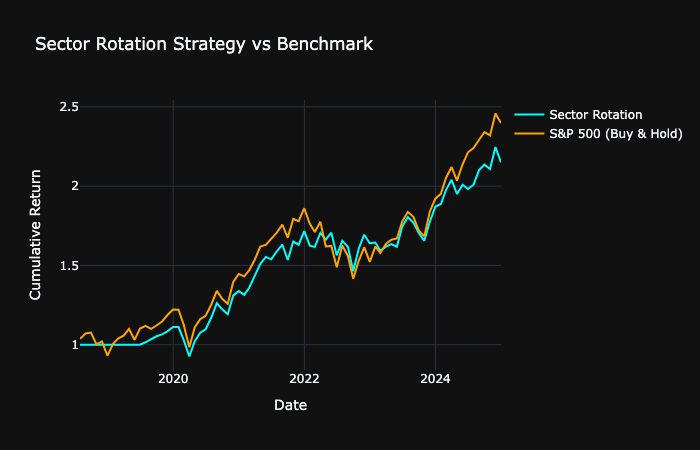

In [29]:
# Compare to benchmark
benchmark_monthly = benchmark_returns.resample('ME').apply(lambda x: (1+x).prod()-1)

# Align dates
common_dates = strategy_results.index.intersection(benchmark_monthly.index)
strat_ret = strategy_results.loc[common_dates, 'return']
bench_ret = benchmark_monthly.loc[common_dates]

# Cumulative
cum_strat = (1 + strat_ret).cumprod()
cum_bench = (1 + bench_ret).cumprod()

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=cum_strat.index, y=cum_strat,
    mode='lines', name='Sector Rotation',
    line=dict(color='cyan', width=2)
))

fig.add_trace(go.Scatter(
    x=cum_bench.index, y=cum_bench,
    mode='lines', name='S&P 500 (Buy & Hold)',
    line=dict(color='orange', width=2)
))

fig.update_layout(
    title='Sector Rotation Strategy vs Benchmark',
    xaxis_title='Date',
    yaxis_title='Cumulative Return',
    template='plotly_dark',
    height=450
)
fig.show()


In [30]:
# Performance metrics
def calc_metrics(returns):
    total_ret = (1 + returns).prod() - 1
    cagr = (1 + total_ret) ** (12/len(returns)) - 1
    vol = returns.std() * np.sqrt(12)
    sharpe = cagr / vol if vol > 0 else 0
    
    # Drawdown
    cum = (1 + returns).cumprod()
    dd = cum / cum.cummax() - 1
    max_dd = dd.min()
    
    return {
        'Total Return': total_ret,
        'CAGR': cagr,
        'Volatility': vol,
        'Sharpe': sharpe,
        'Max Drawdown': max_dd
    }

strat_metrics = calc_metrics(strat_ret)
bench_metrics = calc_metrics(bench_ret)

print("\n" + "="*60)
print("PERFORMANCE COMPARISON")
print("="*60)
print(f"{'Metric':<20} {'Rotation':>15} {'S&P 500':>15}")
print("-"*60)
for metric in strat_metrics:
    s_val = strat_metrics[metric]
    b_val = bench_metrics[metric]
    if 'Return' in metric or 'CAGR' in metric or 'Volatility' in metric or 'Drawdown' in metric:
        print(f"{metric:<20} {s_val*100:>14.2f}% {b_val*100:>14.2f}%")
    else:
        print(f"{metric:<20} {s_val:>15.2f} {b_val:>15.2f}")



PERFORMANCE COMPARISON
Metric                      Rotation         S&P 500
------------------------------------------------------------
Total Return                 115.02%         139.90%
CAGR                          12.50%          14.41%
Volatility                    14.92%          17.53%
Sharpe                          0.84            0.82
Max Drawdown                 -16.74%         -23.93%


## 7. Current Sector Dashboard

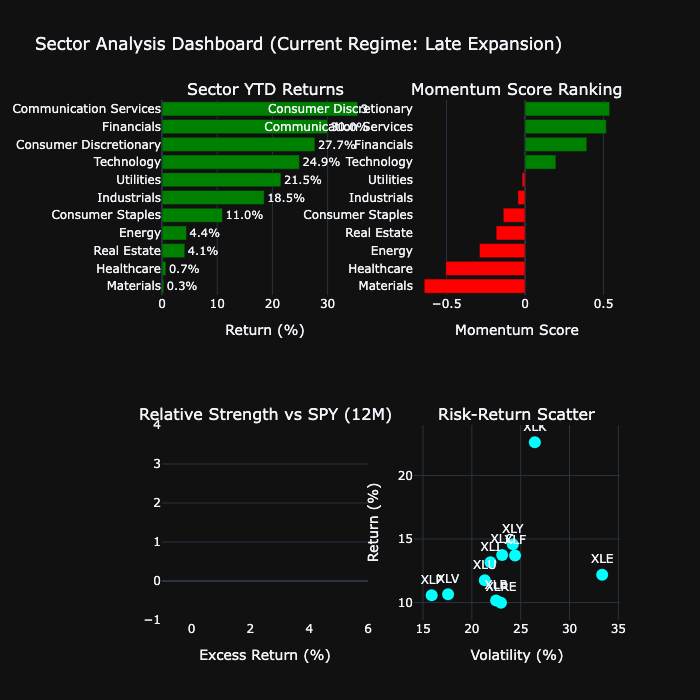

: 

In [ ]:
# Comprehensive sector dashboard
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=['Sector YTD Returns', 'Momentum Score Ranking',
                    'Relative Strength vs SPY (12M)', 'Risk-Return Scatter'],
    specs=[[{}, {}], [{}, {}]]
)

# 1. YTD Returns
ytd_start = f"{prices_df.index[-1].year}-01-01"
ytd_mask = prices_df.index >= ytd_start
ytd_returns = (sector_prices[ytd_mask].iloc[-1] / sector_prices[ytd_mask].iloc[0] - 1).sort_values(ascending=True)

colors = ['green' if x > 0 else 'red' for x in ytd_returns]
fig.add_trace(
    go.Bar(y=[sectors.get(s, s) for s in ytd_returns.index], 
           x=ytd_returns.values * 100,
           orientation='h', marker_color=colors,
           text=[f"{x*100:.1f}%" for x in ytd_returns.values],
           textposition='outside'),
    row=1, col=1
)

# 2. Momentum Ranking
latest_mom = momentum_scores.iloc[-1].sort_values(ascending=True)
colors_mom = ['green' if x > 0 else 'red' for x in latest_mom]
fig.add_trace(
    go.Bar(y=[sectors.get(s, s) for s in latest_mom.index],
           x=latest_mom.values,
           orientation='h', marker_color=colors_mom),
    row=1, col=2
)

# 3. Relative Strength (12M rolling outperformance)
rel_strength = (sector_returns.rolling(252).mean() - benchmark_returns.rolling(252).mean()) * 252
latest_rs = rel_strength.iloc[-1].sort_values(ascending=True).dropna()
colors_rs = ['green' if x > 0 else 'red' for x in latest_rs]
fig.add_trace(
    go.Bar(y=[sectors.get(s, s) for s in latest_rs.index],
           x=latest_rs.values * 100,
           orientation='h', marker_color=colors_rs),
    row=2, col=1
)

# 4. Risk-Return Scatter
ann_ret = sector_returns.mean() * 252
ann_vol = sector_returns.std() * np.sqrt(252)
fig.add_trace(
    go.Scatter(
        x=ann_vol * 100, y=ann_ret * 100,
        mode='markers+text',
        text=list(sector_returns.columns),
        textposition='top center',
        marker=dict(size=12, color='cyan')
    ),
    row=2, col=2
)

fig.update_xaxes(title_text='Return (%)', row=1, col=1)
fig.update_xaxes(title_text='Momentum Score', row=1, col=2)
fig.update_xaxes(title_text='Excess Return (%)', row=2, col=1)
fig.update_xaxes(title_text='Volatility (%)', row=2, col=2)
fig.update_yaxes(title_text='Return (%)', row=2, col=2)

fig.update_layout(
    title=f'Sector Analysis Dashboard (Current Regime: {current_regime})',
    template='plotly_dark',
    height=700,
    showlegend=False
)
fig.show()


## Summary

This CQF-level sector rotation example covered:

1. **Sector ETF Universe**: SPDR Select Sector ETFs representing S&P 500 sectors
2. **Macro Regime Detection**: Business cycle classification using LEI, yield curve, credit spreads
3. **Momentum Scoring**: Multi-timeframe, volatility-adjusted momentum
4. **Sector-Regime Mapping**: Historical performance by economic regime
5. **Dynamic Rotation**: Momentum + regime-aware sector selection
6. **Performance Attribution**: Strategy vs benchmark comparison

**Key Insights for Portfolio Managers:**
- Cyclical sectors (XLI, XLF, XLY) outperform in early expansion
- Defensive sectors (XLP, XLU, XLV) provide downside protection
- Momentum signals can be enhanced with regime context
- Risk-adjusted scoring reduces volatility drag